In [8]:
import pandas as pd
from transformers import pipeline
from sklearn.metrics import classification_report, accuracy_score

In [3]:
df = pd.read_csv('restaurant_reviews.csv')

In [4]:
df.head()

,review_id,text,true_sentiment,true_category
0,1,الاكل لذيذ جدا صراحه جوده وطعم وسعر والمكان نظ...,positive,Food Quality
1,2,تاخر الطلب كثير. نص ساعه عشان احد يجينا وياخذ ...,negative,Waiting Time
2,3,حبيت ان الموظف المحترم amar كان يسمعني شنو انا...,positive,Service & Staff
3,4,ذهبت مرتين للأمانه كل مره احلى من الثانيه اكله...,positive,Food Quality
4,5,المكان رايق وجميل والطعام متنوع ولذيذ وخدمتهم ...,positive,Food Quality


In [5]:
candidate_sentiments = ["positive", "negative", "neutral"]
candidate_categories = ["Food Quality", "Service & Staff", "Price", "Location & Ambience", "Waiting Time"]

## TaskA

In [10]:
class_1 = pipeline("text-classification", model="CAMeL-Lab/bert-base-arabic-camelbert-msa-sentiment")

model_1 = df.copy()

pred_sentiments = []
custom_outputs = []


for text in df['text']:

    res = class_1(text)[0]
    label = res['label'].lower()

    output_dict = {
        'label': label,
        'score': round(float(res['score']), 4),
        'metadata': 'huggingface_AI_model'
    }

    pred_sentiments.append(label)
    custom_outputs.append(output_dict)

model_1['predicted_sentiment'] = pred_sentiments
model_1['custom_output'] = custom_outputs


print(model_1[['text', 'predicted_sentiment', 'custom_output']].head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                                                text predicted_sentiment  \
0  الاكل لذيذ جدا صراحه جوده وطعم وسعر والمكان نظ...            positive   
1  تاخر الطلب كثير. نص ساعه عشان احد يجينا وياخذ ...             neutral   
2  حبيت ان الموظف المحترم amar كان يسمعني شنو انا...            positive   
3  ذهبت مرتين للأمانه كل مره احلى من الثانيه اكله...            positive   
4  المكان رايق وجميل والطعام متنوع ولذيذ وخدمتهم ...            positive   

                                       custom_output  
0  {'label': 'positive', 'score': 0.9734, 'metada...  
1  {'label': 'neutral', 'score': 0.8088, 'metadat...  
2  {'label': 'positive', 'score': 0.9933, 'metada...  
3  {'label': 'positive', 'score': 0.9811, 'metada...  
4  {'label': 'positive', 'score': 0.9688, 'metada...  


In [11]:
acc = accuracy_score(model_1['true_sentiment'], model_1['predicted_sentiment'])
print(f"Overall Accuracy: {acc * 100:.2f}%\n")


print("Classification Report:")
print(classification_report(model_1['true_sentiment'], model_1['predicted_sentiment']))

Overall Accuracy: 78.00%

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75        16
     neutral       0.00      0.00      0.00         7
    positive       0.87      1.00      0.93        27

    accuracy                           0.78        50
   macro avg       0.54      0.58      0.56        50
weighted avg       0.71      0.78      0.74        50



In [22]:
class_2 = pipeline("text-classification", model="ALANZI/imamu_arabic_sentimentAnalysis")

model_2 = df.copy()

pred_sentiments = []
custom_outputs = []


for text in df['text']:

    res = class_2(text)[0]
    label = res['label'].lower()

    output_dict = {
        'label': label,
        'score': round(float(res['score']), 4),
        'metadata': 'huggingface_AI_model'
    }

    pred_sentiments.append(label)
    custom_outputs.append(output_dict)

model_2['predicted_sentiment'] = pred_sentiments
model_2['custom_output'] = custom_outputs


print(model_2[['text', 'predicted_sentiment', 'custom_output']].head())

config.json:   0%|          | 0.00/959 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/305k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/776k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

                                                text predicted_sentiment  \
0  الاكل لذيذ جدا صراحه جوده وطعم وسعر والمكان نظ...            positive   
1  تاخر الطلب كثير. نص ساعه عشان احد يجينا وياخذ ...            negative   
2  حبيت ان الموظف المحترم amar كان يسمعني شنو انا...            positive   
3  ذهبت مرتين للأمانه كل مره احلى من الثانيه اكله...            positive   
4  المكان رايق وجميل والطعام متنوع ولذيذ وخدمتهم ...            positive   

                                       custom_output  
0  {'label': 'positive', 'score': 0.9998, 'metada...  
1  {'label': 'negative', 'score': 0.9908, 'metada...  
2  {'label': 'positive', 'score': 0.9988, 'metada...  
3  {'label': 'positive', 'score': 0.9962, 'metada...  
4  {'label': 'positive', 'score': 0.9952, 'metada...  


In [27]:
acc = accuracy_score(model_2['true_sentiment'], model_2['predicted_sentiment'])
print(f"Overall Accuracy: {acc * 100:.2f}%\n")


print("Classification Report:")
print(classification_report(model_2['true_sentiment'], model_2['predicted_sentiment']))

Overall Accuracy: 76.00%

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.62      0.71        16
     neutral       0.33      0.57      0.42         7
    positive       0.92      0.89      0.91        27

    accuracy                           0.76        50
   macro avg       0.70      0.70      0.68        50
weighted avg       0.81      0.76      0.78        50



In [19]:
class_3 = pipeline("text-classification", model="Ammar-alhaj-ali/arabic-MARBERT-sentiment")

model_3 = df.copy()

pred_sentiments = []
custom_outputs = []


for text in df['text']:

    res = class_3(text)[0]
    label = res['label'].lower()

    output_dict = {
        'label': label,
        'score': round(float(res['score']), 4),
        'metadata': 'huggingface_AI_model'
    }

    pred_sentiments.append(label)
    custom_outputs.append(output_dict)

model_3['predicted_sentiment'] = pred_sentiments
model_3['custom_output'] = custom_outputs


print(model_3[['text', 'predicted_sentiment', 'custom_output']].head())

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  651MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/371 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  651MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.69M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

                                                text predicted_sentiment  \
0  الاكل لذيذ جدا صراحه جوده وطعم وسعر والمكان نظ...            positive   
1  تاخر الطلب كثير. نص ساعه عشان احد يجينا وياخذ ...             neutral   
2  حبيت ان الموظف المحترم amar كان يسمعني شنو انا...            positive   
3  ذهبت مرتين للأمانه كل مره احلى من الثانيه اكله...            positive   
4  المكان رايق وجميل والطعام متنوع ولذيذ وخدمتهم ...            positive   

                                       custom_output  
0  {'label': 'positive', 'score': 0.9791, 'metada...  
1  {'label': 'neutral', 'score': 0.6052, 'metadat...  
2  {'label': 'positive', 'score': 0.9699, 'metada...  
3  {'label': 'positive', 'score': 0.9659, 'metada...  
4  {'label': 'positive', 'score': 0.9708, 'metada...  


In [20]:
acc = accuracy_score(model_3['true_sentiment'], model_3['predicted_sentiment'])
print(f"Overall Accuracy: {acc * 100:.2f}%\n")


print("Classification Report:")
print(classification_report(model_3['true_sentiment'], model_3['predicted_sentiment']))

Overall Accuracy: 78.00%

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.56      0.69        16
     neutral       0.36      0.57      0.44         7
    positive       0.90      0.96      0.93        27

    accuracy                           0.78        50
   macro avg       0.72      0.70      0.69        50
weighted avg       0.82      0.78      0.79        50



## TaskB

In [30]:
zero_shot_classifier = pipeline("zero-shot-classification", model="vicgalle/xlm-roberta-large-xnli-anli")
model_0 = df.copy()

pred_categories = []
custom_zero_shot_outputs = []


for text in model_0['text']:

    res = zero_shot_classifier(text, candidate_labels=candidate_categories)


    top_category = res['labels'][0]
    top_score = res['scores'][0]


    custom_dict = {
        'label': top_category,
        'score': round(float(top_score), 4),
        'metadata': 'huggingface_AI_model'
    }

    pred_categories.append(top_category)
    custom_zero_shot_outputs.append(custom_dict)


model_0['predicted_category'] = pred_categories
model_0['custom_output'] = custom_zero_shot_outputs

display(model_0[['text', 'true_category', 'predicted_category', 'custom_output']].head())

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

,text,true_category,predicted_category,custom_output
0,الاكل لذيذ جدا صراحه جوده وطعم وسعر والمكان نظ...,Food Quality,Food Quality,"{'label': 'Food Quality', 'score': 0.7272, 'me..."
1,تاخر الطلب كثير. نص ساعه عشان احد يجينا وياخذ ...,Waiting Time,Waiting Time,"{'label': 'Waiting Time', 'score': 0.9928, 'me..."
2,حبيت ان الموظف المحترم amar كان يسمعني شنو انا...,Service & Staff,Service & Staff,"{'label': 'Service & Staff', 'score': 0.994, '..."
3,ذهبت مرتين للأمانه كل مره احلى من الثانيه اكله...,Food Quality,Food Quality,"{'label': 'Food Quality', 'score': 0.7869, 'me..."
4,المكان رايق وجميل والطعام متنوع ولذيذ وخدمتهم ...,Food Quality,Service & Staff,"{'label': 'Service & Staff', 'score': 0.4099, ..."


In [31]:
acc_zs = accuracy_score(model_0['true_category'], model_0['predicted_category'])
print(f"Zero-Shot Category Accuracy: {acc_zs * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(model_0['true_category'], model_0['predicted_category']))

Zero-Shot Category Accuracy: 52.00%

Classification Report:
                     precision    recall  f1-score   support

       Food Quality       0.45      0.56      0.50        18
Location & Ambience       0.33      0.60      0.43         5
              Price       0.80      0.80      0.80         5
    Service & Staff       0.62      0.38      0.47        21
       Waiting Time       1.00      1.00      1.00         1

           accuracy                           0.52        50
          macro avg       0.64      0.67      0.64        50
       weighted avg       0.56      0.52      0.52        50



## erroe

In [34]:
errors_task_a = model_3[model_3['true_sentiment'] != model_3['predicted_sentiment']]

print(f"=== أخطاء Task A (عدد الأخطاء: {len(errors_task_a)}) ===")
display(errors_task_a[['review_id', 'text', 'true_sentiment', 'predicted_sentiment']])

# --- استخراج أخطاء Task B (Zero-Shot Classification) ---
errors_task_b = model_0[model_0['true_category'] != model_0['predicted_category']]

print(f"\n=== أخطاء Task B (عدد الأخطاء: {len(errors_task_b)}) ===")
display(errors_task_b[['review_id', 'text', 'true_category', 'predicted_category']])

=== أخطاء Task A (عدد الأخطاء: 11) ===


,review_id,text,true_sentiment,predicted_sentiment
1,2,تاخر الطلب كثير. نص ساعه عشان احد يجينا وياخذ ...,negative,neutral
9,10,المطعم فلس طيني والطاقم مصري طلبت مشكل مشاوي ل...,negative,neutral
23,24,الاكل جدا لذيذ والمكان نظيف ومرتب والاطلاله اج...,neutral,negative
25,26,بصراحة ماخذ صيت اكبر من اللازم والطعم بالنسبة ...,negative,positive
27,28,المكان اطلالته وجلسته شرحة و حلوة ، لكن الاكل ...,neutral,positive
38,39,انا من الزوار الدائمين لفرع الرياض ، شتّان بين...,negative,neutral
39,40,ممتاز ثاني مرة اجربه مع العلم تجربتي امس كانه ...,neutral,positive
41,42,تم زيادة الاسعار وعدم توافقها مع اسعار قائمة ا...,negative,neutral
44,45,جربت الإفطار جيد,positive,neutral
45,46,مشكلته عدم توفر بعض الاطباق وارتفاع الاسعار شوي,negative,neutral



=== أخطاء Task B (عدد الأخطاء: 24) ===


,review_id,text,true_category,predicted_category
4,5,المكان رايق وجميل والطعام متنوع ولذيذ وخدمتهم ...,Food Quality,Service & Staff
5,6,كل ماجي البحرين لازم امرهم اكلهم لذيذ واسلوبهم...,Service & Staff,Food Quality
7,8,للأسف، الموظفين ما أحسنوا الخدمة! لشخصين، جربن...,Price,Service & Staff
9,10,المطعم فلس طيني والطاقم مصري طلبت مشكل مشاوي ل...,Food Quality,Service & Staff
11,12,المطعم ممتاز والاكل طيب والمكان وتفاصيل المكان...,Service & Staff,Food Quality
13,14,زبون دائما ولاكن هذا المره المطعم مختلف تماماً...,Food Quality,Service & Staff
16,17,الاخت مار خدمتنا بشكل جيد اكل جيد طلبنا فخاره ...,Service & Staff,Food Quality
17,18,المكان يجنن و فريد من نوعه تجربه حلوه ، عندهم ...,Service & Staff,Location & Ambience
18,19,أنا زبون للمطعم هذا من 3 سنوات، والشيء اللي يخ...,Service & Staff,Food Quality
19,20,جيت اتعشى في مطعم الكوفية لأول مرة. اكلت لحم ر...,Food Quality,Price


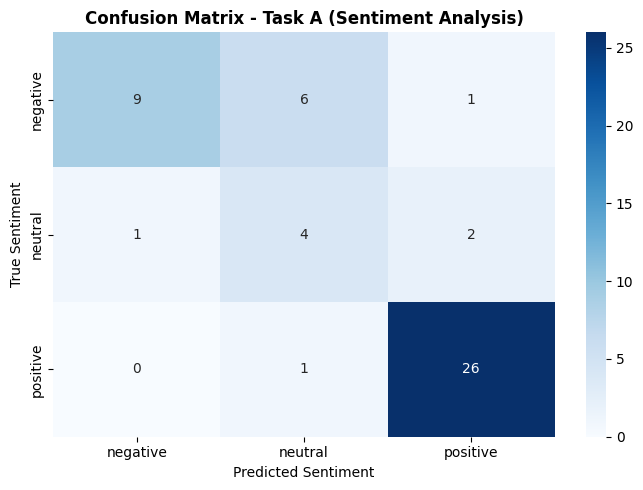

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


sentiment_labels = ['negative', 'neutral', 'positive']


cm_task_a = confusion_matrix(model_3['true_sentiment'], model_3['predicted_sentiment'], labels=sentiment_labels)


plt.figure(figsize=(7, 5))
sns.heatmap(cm_task_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=sentiment_labels, yticklabels=sentiment_labels)

plt.title('Confusion Matrix - Task A (Sentiment Analysis)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.tight_layout()
plt.show()

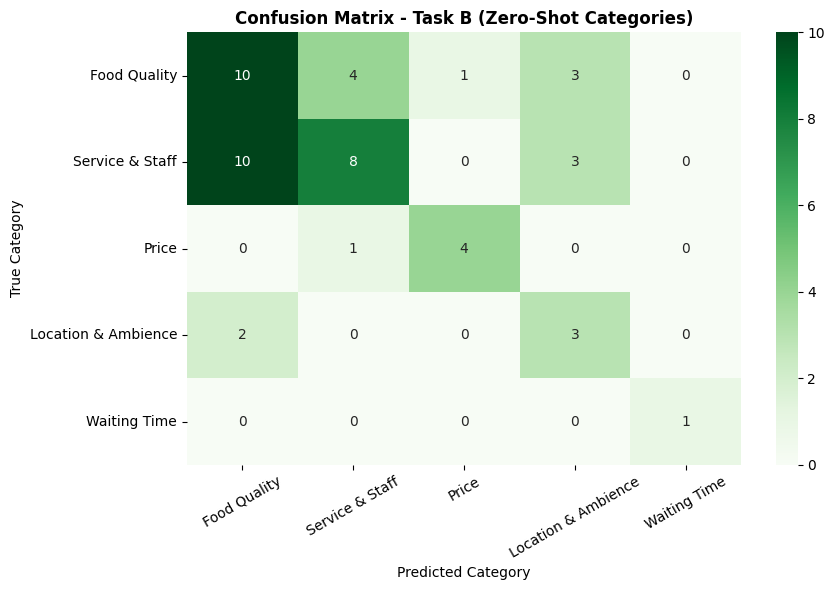

In [36]:
category_labels = ["Food Quality", "Service & Staff", "Price", "Location & Ambience", "Waiting Time"]

cm_task_b = confusion_matrix(model_0['true_category'], model_0['predicted_category'], labels=category_labels)

plt.figure(figsize=(9, 6))
sns.heatmap(cm_task_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=category_labels, yticklabels=category_labels)

plt.title('Confusion Matrix - Task B (Zero-Shot Categories)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()